# Exponential Distribution

The **Exponential** distribution models the **waiting time** between events in a Poisson process.

| Property | Value |
|----------|-------|
| **Notation** | $X \sim \text{Exp}(\lambda)$ |
| **Description** | Waiting time between Poisson events |
| **Parameter** | $\lambda$ = rate (events per unit time) |
| **Support** | $[0, \infty)$ |
| **PDF** | $f(x) = \lambda e^{-\lambda x}$ for $x \geq 0$ |
| **CDF** | $F(x) = 1 - e^{-\lambda x}$ |
| **Expectation** | $E[X] = 1/\lambda$ |
| **Variance** | $\text{Var}(X) = 1/\lambda^2$ |

**Relationship:** If events arrive at rate $\lambda$ (Poisson), the time between arrivals is $\text{Exp}(\lambda)$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

print("Libraries loaded!")

Libraries loaded!


---
## 1. PDF and CDF

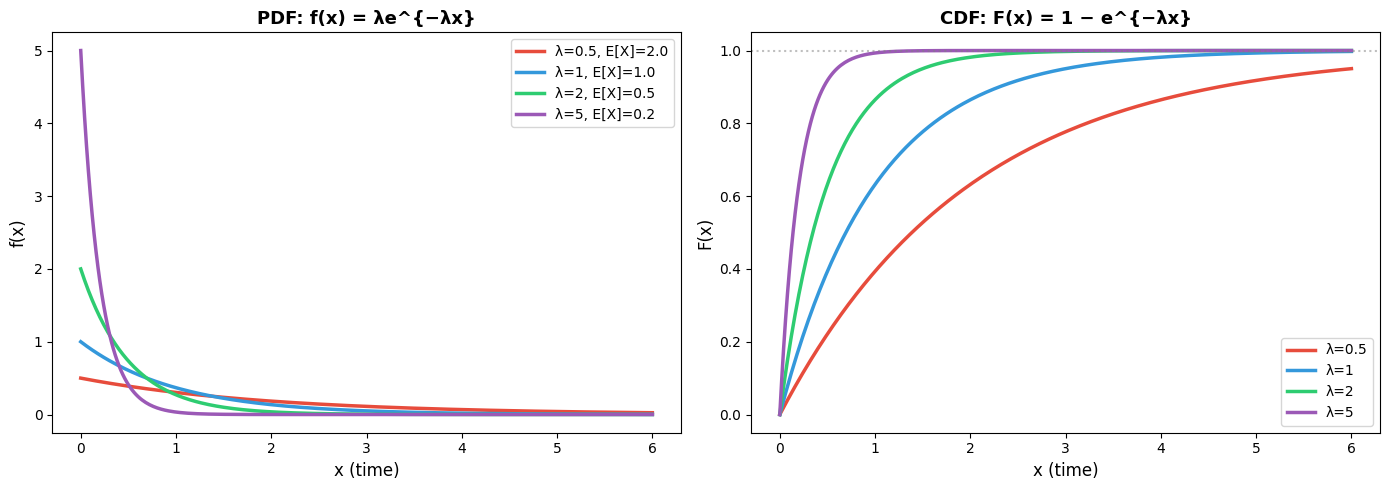

Higher rate (λ) → shorter expected waiting time → steeper decay


In [2]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

lambdas = [0.5, 1, 2, 5]
colors = ['#e74c3c', '#3498db', '#2ecc71', '#9b59b6']
x = np.linspace(0, 6, 300)

for lam, color in zip(lambdas, colors):
    rv = stats.expon(scale=1/lam)
    axes[0].plot(x, rv.pdf(x), color=color, linewidth=2.5,
                 label=f'λ={lam}, E[X]={1/lam:.1f}')
    axes[1].plot(x, rv.cdf(x), color=color, linewidth=2.5,
                 label=f'λ={lam}')

axes[0].set_title('PDF: f(x) = λe^{−λx}', fontsize=13, fontweight='bold')
axes[0].set_xlabel('x (time)', fontsize=12)
axes[0].set_ylabel('f(x)', fontsize=12)
axes[0].legend(fontsize=10)

axes[1].set_title('CDF: F(x) = 1 − e^{−λx}', fontsize=13, fontweight='bold')
axes[1].set_xlabel('x (time)', fontsize=12)
axes[1].set_ylabel('F(x)', fontsize=12)
axes[1].legend(fontsize=10)
axes[1].axhline(1, color='gray', linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()
print("Higher rate (λ) → shorter expected waiting time → steeper decay")

---
## 2. Memoryless Property

$$P(X > s + t \mid X > s) = P(X > t)$$

The Exponential is the **only** continuous distribution with the memoryless property.
(Just like Geometric is the only discrete one.)

Memoryless Property: P(X > s+t | X > s) = P(X > t)
  P(X > 3)          = 0.0494  (theory: 0.0498)
  P(X > 5 | X > 2)  = 0.0502  (should ≈ 0.0498)
  Match ✓


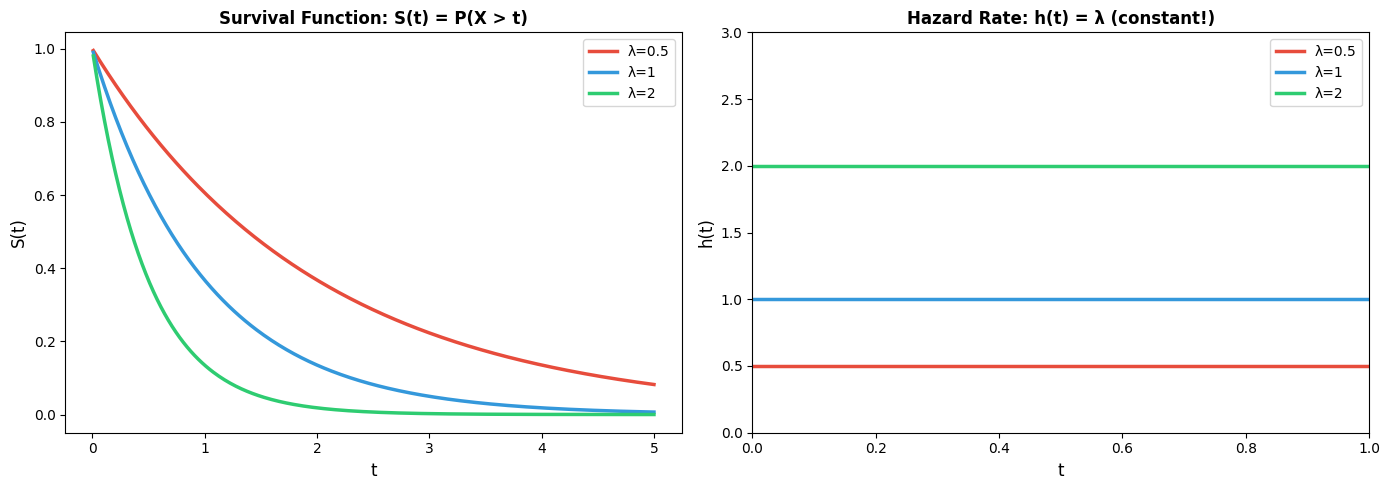

Constant hazard rate ↔ memoryless property


In [3]:
# Demonstrate memoryless property
np.random.seed(42)
lam = 1.0
n = 200000

samples = stats.expon.rvs(scale=1/lam, size=n)

# P(X > 3)
p_gt_3 = np.mean(samples > 3)
p_gt_3_theory = np.exp(-lam * 3)

# P(X > 5 | X > 2) should equal P(X > 3)
conditioned = samples[samples > 2]
p_gt_5_given_gt_2 = np.mean(conditioned > 5)

print("Memoryless Property: P(X > s+t | X > s) = P(X > t)")
print(f"  P(X > 3)          = {p_gt_3:.4f}  (theory: {p_gt_3_theory:.4f})")
print(f"  P(X > 5 | X > 2)  = {p_gt_5_given_gt_2:.4f}  (should ≈ {p_gt_3_theory:.4f})")
print(f"  Match ✓" if abs(p_gt_3 - p_gt_5_given_gt_2) < 0.01 else "  Close enough")

# Visual: hazard rate is constant
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

t = np.linspace(0.01, 5, 300)

# Survival function S(t) = P(X > t) = e^{-λt}
ax = axes[0]
for l, c in zip([0.5, 1, 2], ['#e74c3c', '#3498db', '#2ecc71']):
    rv = stats.expon(scale=1/l)
    ax.plot(t, rv.sf(t), color=c, linewidth=2.5, label=f'λ={l}')
ax.set_title('Survival Function: S(t) = P(X > t)', fontsize=12, fontweight='bold')
ax.set_xlabel('t', fontsize=12)
ax.set_ylabel('S(t)', fontsize=12)
ax.legend(fontsize=10)

# Hazard rate h(t) = f(t)/S(t) = λ (constant!)
ax = axes[1]
for l, c in zip([0.5, 1, 2], ['#e74c3c', '#3498db', '#2ecc71']):
    ax.axhline(l, color=c, linewidth=2.5, label=f'λ={l}')
ax.set_title('Hazard Rate: h(t) = λ (constant!)', fontsize=12, fontweight='bold')
ax.set_xlabel('t', fontsize=12)
ax.set_ylabel('h(t)', fontsize=12)
ax.legend(fontsize=10)
ax.set_ylim(0, 3)

plt.tight_layout()
plt.show()
print("Constant hazard rate ↔ memoryless property")

---
## 3. Connection to Poisson

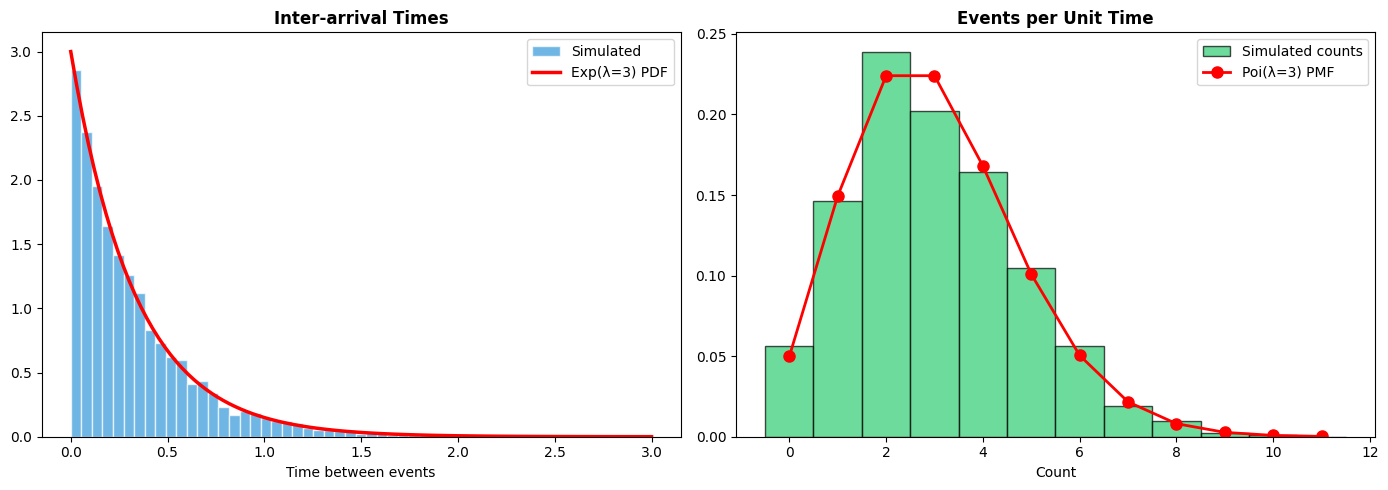

Exponential inter-arrivals → Poisson counts ✓


In [4]:
# Simulate Poisson arrivals → Exponential inter-arrival times
np.random.seed(42)
lam = 3  # 3 events per unit time

# Generate Poisson process: inter-arrival times are Exp(λ)
n_events = 10000
inter_arrivals = stats.expon.rvs(scale=1/lam, size=n_events)
arrival_times = np.cumsum(inter_arrivals)

# Count events in each unit interval → should be Poisson(λ)
T = 1000  # observe for T time units
counts_per_interval = np.array([
    np.sum((arrival_times >= t) & (arrival_times < t + 1))
    for t in range(int(T))
])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Inter-arrival time distribution
ax = axes[0]
x = np.linspace(0, 3, 100)
ax.hist(inter_arrivals[:5000], bins=50, density=True, color='#3498db',
        edgecolor='white', alpha=0.7, label='Simulated')
ax.plot(x, stats.expon.pdf(x, scale=1/lam), 'r-', linewidth=2.5,
        label=f'Exp(λ={lam}) PDF')
ax.set_title('Inter-arrival Times', fontsize=12, fontweight='bold')
ax.set_xlabel('Time between events')
ax.legend(fontsize=10)

# Count distribution
ax = axes[1]
k = np.arange(0, 12)
ax.hist(counts_per_interval, bins=np.arange(-0.5, 12.5, 1), density=True,
        color='#2ecc71', edgecolor='black', alpha=0.7, label='Simulated counts')
ax.plot(k, stats.poisson.pmf(k, lam), 'ro-', linewidth=2, markersize=8,
        label=f'Poi(λ={lam}) PMF')
ax.set_title('Events per Unit Time', fontsize=12, fontweight='bold')
ax.set_xlabel('Count')
ax.legend(fontsize=10)

plt.tight_layout()
plt.show()
print(f"Exponential inter-arrivals → Poisson counts ✓")

---
## 4. Practical Examples

In [5]:
from scipy.stats import expon

# Example 1: Server response time
lam = 0.5  # avg 0.5 requests/second → mean wait = 2 sec
X = expon(scale=1/lam)
print("Server (avg response = 2 sec, λ = 0.5):")
print(f"  P(X ≤ 1 sec) = {X.cdf(1):.4f}")
print(f"  P(X > 5 sec) = {X.sf(5):.4f}")
print(f"  P(2 < X ≤ 4) = {X.cdf(4) - X.cdf(2):.4f}")

# Example 2: Light bulb lifetime
mean_life = 1000  # hours
lam_bulb = 1 / mean_life
Y = expon(scale=mean_life)
print(f"\nLight bulb (mean life = {mean_life} hrs):")
print(f"  P(lasts > 500 hrs)  = {Y.sf(500):.4f}")
print(f"  P(lasts > 2000 hrs) = {Y.sf(2000):.4f}")
print(f"  Median lifetime     = {Y.median():.1f} hrs")
print(f"  (Note: median < mean for exponential)")

Server (avg response = 2 sec, λ = 0.5):
  P(X ≤ 1 sec) = 0.3935
  P(X > 5 sec) = 0.0821
  P(2 < X ≤ 4) = 0.2325

Light bulb (mean life = 1000 hrs):
  P(lasts > 500 hrs)  = 0.6065
  P(lasts > 2000 hrs) = 0.1353
  Median lifetime     = 693.1 hrs
  (Note: median < mean for exponential)


---
## Summary

| Property | Formula |
|----------|---------|
| PDF | $f(x) = \lambda e^{-\lambda x}$ for $x \geq 0$ |
| CDF | $F(x) = 1 - e^{-\lambda x}$ |
| $E[X]$ | $1/\lambda$ |
| $\text{Var}(X)$ | $1/\lambda^2$ |
| Memoryless | $P(X > s+t \mid X > s) = P(X > t)$ |
| Poisson link | Inter-arrival times of Poi($\lambda$) process |
| Python | `scipy.stats.expon(scale=1/λ)` |

**Next:** Normal Distribution — the most important distribution.